In [12]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
f_sig = "../coffea/AllInOne_2022/Resolution_DSCBsigma.coffea"

sig_histo = util.load(f_sig) [0]


Saved: ./plots/signal_2018/ptvslxy.png


Hist(
  Variable(array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.]), name='Gen_pt'),
  Regular(200, -1, 1, name='Res_LPT'),
  storage=Weight()) # Sum: WeightedSum(value=158, variance=158) (WeightedSum(value=166, variance=166) with flow)

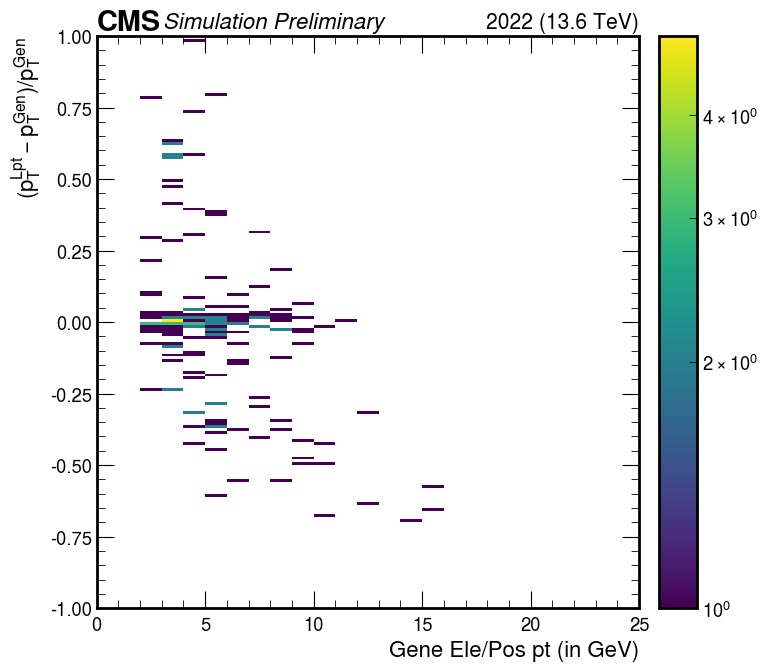

In [18]:
fig, ax = plt.subplots(figsize=(7,7))


# Plot settings
plot_dict = {
    'variable':'res_LPT_gen_ptbin',
    'cut': 'cut1',
    'year': 2022
}


style_2d_dict = {
    'fig': fig,
    'ax': ax,
    'xrebin': None,
    'yrebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]  
    'ylim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doLogz': True,
    'xlabel': "Gene Ele/Pos pt (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': r'$(p_{T}^{\mathrm{Lpt}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'zlabel': None,   
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'ptvslxy.png'
}

#signal points
m1 = 10
delta =0.1
ctau =10


ptools.plot_signal_2D(sig_histo, m1, delta, ctau, plot_dict, style_2d_dict)


Hist(
  Variable(array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.]), name='Gen_pt'),
  Regular(200, -1, 1, name='Res_GED'),
  storage=Weight()) # Sum: WeightedSum(value=159, variance=159) (WeightedSum(value=166, variance=166) with flow)
<class 'hist.hist.Hist'>


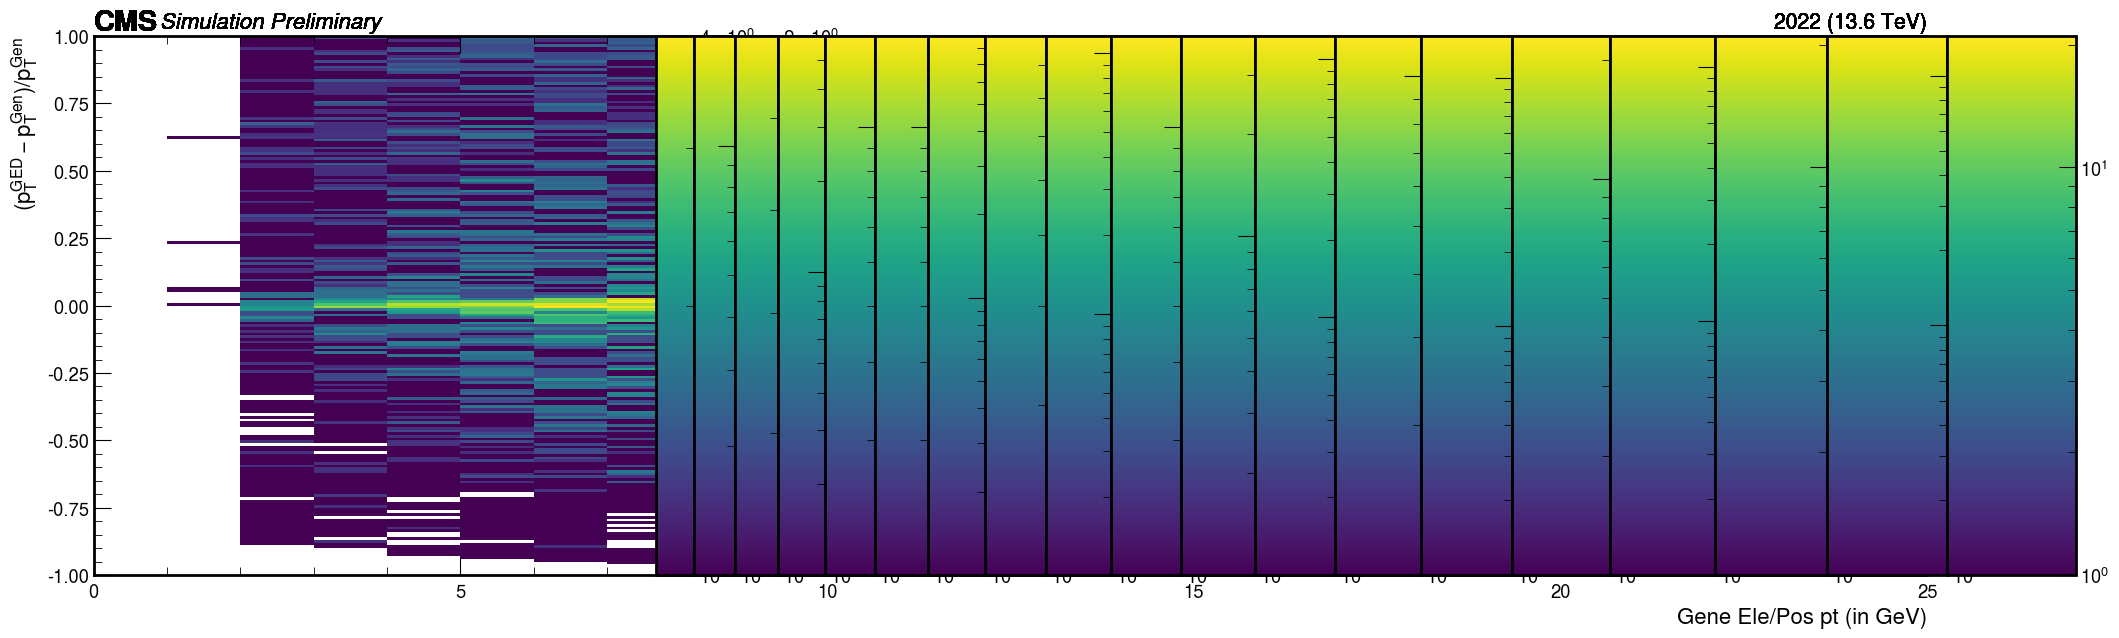

In [42]:
fig, ax = plt.subplots(figsize=(7,7))


# Plot settings
plot_dict = {
    'variable':'res_GED_gen_ptbin',
    'cut': 'cut1',
    'year': 2022
}


style_2d_dict = {
    'fig': fig,
    'ax': ax,
    'xrebin': None,
    'yrebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]  
    'ylim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doLogz': True,
    'xlabel': "Gene Ele/Pos pt (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'zlabel': None,   
    'flow': None,     # overflow
    'doSave': False,
    'outDir': './plots/signal_2018',
    'outName': f'ptvslxy.png'
}

#signal points
samples = {
    10: 
    {
        0.1: [10],
        0.2: [1,100],
    },
    20: 
    {
        
        0.2: [1, 100],
    },
    30: 
    {
        0.1: [10],
        0.2: [1,100]
    },
    40: 
    {
        0.2: [1, 100],
    },
    50:
    {
        0.1: [10],
        0.2: [1,100],
    },
    60:
    {
         0.2: [1,100],
    },
    70:
    {
         0.2: [1,100],
    },
    80:
    {
         0.2: [1,100],
    }
 
}


h_list_lpt=[]
h_sum_lpt = None

for m1,deltas in samples.items():
    for delta, ctaus in deltas.items():
        for ctau in ctaus:
            h_lpt = ptools.plot_signal_2D(sig_histo, m1, delta, ctau, plot_dict, style_2d_dict)
            h_list_lpt.append(h_lpt)            
            if h_sum_lpt is None:
                h_sum_lpt = h_lpt.copy()
                print (h_sum_lpt)
            else:
                h_sum_lpt += h_lpt

counts_lpt = h_sum_lpt.values()
edges_lpt = h_sum_lpt.axes[0].edges

bin_x_lpt = (edges_lpt[1:]+edges_lpt[:-1])/2

variances_lpt = h_sum_lpt.variances()
yerr_lpt = np.sqrt(variances_lpt)

print (type(h_lpt))

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(
/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(
/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (->

Text(0, 1, 'Entries')

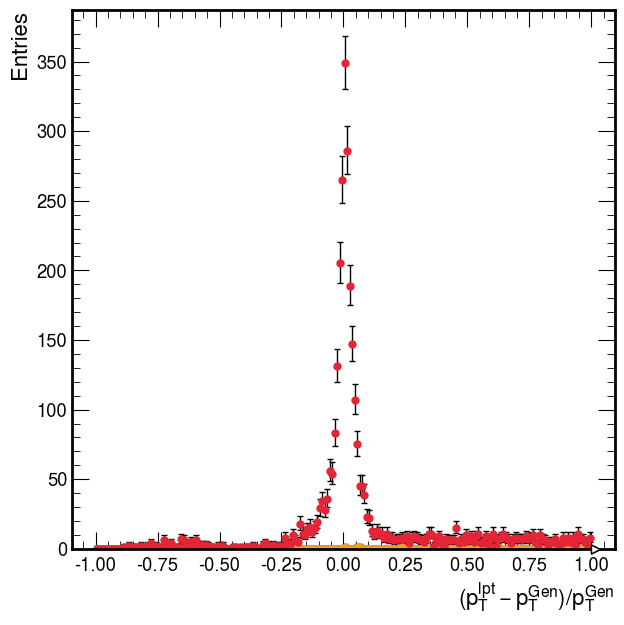

In [44]:
fig, ax = plt.subplots(figsize=(7,7))

COUNTS = []
EDGES = []
BINSX =[]
VARIANCES = []
YERR = []

for i in range (0,3):
    mplhep.histplot(h_sum_lpt[i,:], histtype='errorbar',yerr=True, fmt='o', capsize=2, ecolor='black')
    
    counts_lpt = h_sum_lpt[i,:].values()
    COUNTS.append(counts_lpt)
    edges_lpt = h_sum_lpt[i,:].axes[0].edges
    EDGES.append(edges_lpt)   

    bin_x_lpt = (edges_lpt[1:]+edges_lpt[:-1])/2
    BINSX.append(bin_x_lpt)

    variances_lpt = h_sum_lpt[i,:].variances()
    VARIANCES.append(variances_lpt)
    
    yerr_lpt = np.sqrt(variances_lpt)
    YERR.append(yerr_lpt)
    
    
plt.xlabel(r'$(p_{T}^{\mathrm{lpt}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$')
plt.ylabel("Entries")



In [18]:
#1. Define your model

def double_cb(x,u,sig, nl, a_l, nr, a_r,N):
    t=(x-u)/(sig)
    al = abs(a_l)
    ar = abs(a_r)

    left_tail = t < -al
    core = (t>-al) & (t<ar)
    right_tail = t > ar

    y=np.empty_like(t)

    y[core] = np.exp(-0.5*t[core]*t[core])

    A_L = (nl / al)**nl * np.exp(-0.5 * al**2)
    B_L = (nl / al) - al
    y[left_tail] = A_L / (B_L - t[left_tail])**nl

    A_R = (nr / ar)**nr * np.exp(-0.5 * ar**2)
    B_R = (nr / ar) - ar
    y[right_tail] = A_R / (B_R + t[right_tail])**nr

    return N*y


In [60]:
xdata = BINSX
ydata = COUNTS

ydata_new =[]
xdata_new = []
for j in ydata:
    mask = j >0    
    ydata_new.append(j[mask])
    xdata
    
#     xdata_new.append(
# print (ydata_new)



# xdata_new = xdata[mask]

# yerr_new_lpt = YERR[mask]

TypeError: only integer scalar arrays can be converted to a scalar index